# Module 2 — Predicting reported biodiversity impact of SLM technologies with neural networks

**Research question.** `research.md` frames Module 2 as a supervised problem: what separates the SLM
technologies that report a *high* improvement in biodiversity from those that report a *low* one?
We keep that framing and add the half that matters most to WOCAT: among the documented SLM methods
(groups and measures), which ones go together with the largest reported biodiversity gains once we
account for where they are applied?

**What this notebook builds on**

* Dima's data exploration (`colab/01_wocat_explore.ipynb`) gave us the tidy tables and three rules
  we follow throughout: split the target at the **median** (84 % of all impact scores are positive),
  **group cross-validation by country** (sites and compilers cluster geographically), and treat the
  scores as **reported** impact, never as causal effect (compiler averages differ by two points on a
  seven-point scale).
* Norman's Module 1 clustering (`module1_kmeans_clustering.ipynb`) showed that the structure of the
  data is dominated by the agro-climatic zone: environment first, practice second.

**What we do here (Module 2)**

1. Three classical **yardsticks** (majority class, logistic regression, random forest).
2. **Method 1 — a regularised deep feed-forward network**: He initialisation, batch normalisation,
   dropout, L2, Adam, a learning-rate schedule and early stopping, tuned on a small grid.
3. **Method 2 — a multi-task network** that predicts the high/low label *and* all eight individual
   biodiversity indicators of questionnaire section 6.1 at once, with a custom loss that tolerates
   missing indicators.
4. **The answer**: a what-if analysis with the multi-task network that ranks SLM groups with the
   environment held fixed, a method × indicator heat-map, and a permutation test of which feature
   blocks the network actually uses.

**Key results, in one paragraph.** Every model, classical or neural, lands within a few
hundredths of AUC 0.55 on unseen countries (random forest 0.56, feed-forward net 0.55, multi-task
net 0.55, logistic regression 0.52). The individual biodiversity indicators are not predictable
beyond their means. What the data does support is a consistent *ranking of reported impact*:
vegetation-building methods (forest management, crop–livestock integration, agroforestry) lead in
every view, soil- and water-engineering methods (cross-slope structures, soil disturbance,
disaster-risk reduction) trail, and part of every method's raw advantage is *where* it is used. The
questionnaire fields that matter most are the compiler's stated intent (the degradation type
addressed, the main purpose) — which is Dima's rater warning in another guise.

Run time: about 10 minutes on a laptop CPU. Kernel: **Python (CAS AML)**.

## 1. Setup

In [1]:
import os, sys, time, math, warnings
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"   # reproducible numerics on CPU

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

import sklearn
import tensorflow as tf
import keras
from keras import layers

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")
SEED = 42
keras.utils.set_random_seed(SEED)

print(f"python {sys.version.split()[0]} | pandas {pd.__version__} | scikit-learn {sklearn.__version__} | "
      f"tensorflow {tf.__version__} | keras {keras.__version__}")

# plotting conventions
C_BLUE, C_ORANGE, C_AQUA, C_RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
INK, INK_MUTED, GRID, NEUTRAL = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
BLUES = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#3987e5", "#0d366b"])
BLUE_RED = LinearSegmentedColormap.from_list("blue_red", ["#104281", "#f0efec", "#b03030"])
plt.rc("font", size=11); plt.rc("axes", titlesize=12, labelsize=11, edgecolor=NEUTRAL, labelcolor=INK, axisbelow=True)
plt.rc("grid", color=GRID, linewidth=0.8); plt.rc("xtick", color=INK_MUTED); plt.rc("ytick", color=INK_MUTED)
plt.rc("legend", frameon=False, fontsize=10); plt.rc("figure", facecolor="white", dpi=100)

def tidy(ax, grid_axis="y"):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.grid(False)
    if grid_axis:
        ax.grid(True, axis=grid_axis)
    return ax

python 3.13.15 | pandas 3.0.5 | scikit-learn 1.9.0 | tensorflow 2.21.0 | keras 3.15.1


## 2. Data and targets

Two tables from Dima's notebook: one row per technology (1 540 × 51) and one row per individual
impact score (23 802). The biodiversity block of the questionnaire (section 6.1) asks for a −3 … +3
rating of eight indicators; a technology scores only the ones its compiler considered relevant.

In [2]:
def find_data_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "colab" / "datasets" / "wocat"
        if (candidate / "wocat_technologies.csv.gz").is_file():
            return candidate
    raise FileNotFoundError("run this notebook from inside the CAS-AML-WOCAT repository")

DATA = find_data_dir()
wocat = pd.read_csv(DATA / "wocat_technologies.csv.gz")
scores = pd.read_csv(DATA / "impact_scores.csv.gz")

PRETTY = {"vegetation_cover": "Vegetation cover", "biomass_above_ground_C": "Biomass / above-ground C",
          "plant_diversity": "Plant diversity", "animal_diversity": "Animal diversity",
          "beneficial_species": "Beneficial species", "habitat_diversity": "Habitat diversity",
          "invasive_alien_species": "Invasive alien species", "pest_disease_control": "Pest / disease control"}
BIO = list(PRETTY)

bio_wide = (scores[scores["block"] == "ecological_biodiversity"]
            .pivot_table(index="technology_id", columns="indicator", values="value", aggfunc="mean").reindex(columns=BIO))
data = wocat.merge(bio_wide, left_on="technology_id", right_index=True, how="inner").reset_index(drop=True)
data["bio_mean"] = data[BIO].mean(axis=1)
MEDIAN = data["bio_mean"].median()
data["bio_high"] = (data["bio_mean"] > MEDIAN).astype(int)
y = data["bio_high"].to_numpy()
Y_IND = data[BIO].to_numpy(dtype=np.float32)          # NaN where an indicator was not scored

print(f"{len(wocat):,} technologies, {len(scores):,} individual scores; "
      f"{len(data)} technologies have at least one biodiversity indicator")
print(f"median biodiversity score = {MEDIAN:.2f}; share of class 'high' = {y.mean():.2f}\n")
print(pd.DataFrame({"records scored": data[BIO].notna().sum().values, "mean score": data[BIO].mean().round(2).values,
                    "share > 0": (data[BIO] > 0).mean().round(2).values}, index=[PRETTY[b] for b in BIO]).to_string())

1,540 technologies, 23,802 individual scores; 895 technologies have at least one biodiversity indicator
median biodiversity score = 1.67; share of class 'high' = 0.49

                          records scored  mean score  share > 0
Vegetation cover                     350        1.86       0.37
Biomass / above-ground C             479        1.92       0.51
Plant diversity                      475        1.75       0.49
Animal diversity                     249        1.52       0.25
Beneficial species                   281        1.64       0.30
Habitat diversity                    338        1.54       0.33
Invasive alien species                98        0.97       0.07
Pest / disease control               255        0.54       0.15


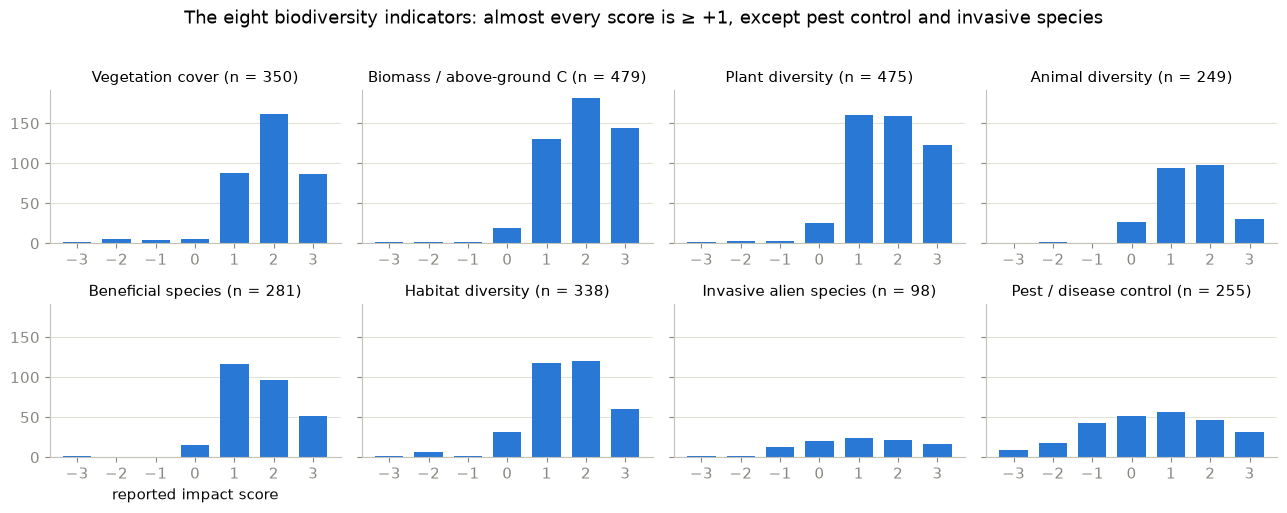

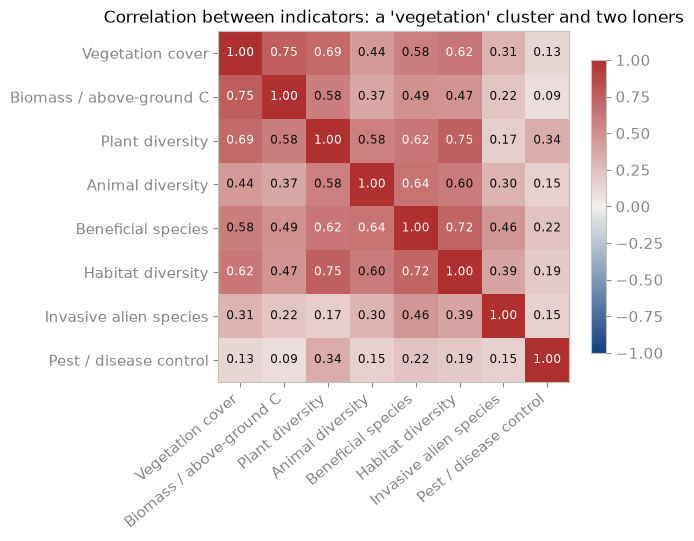

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5), sharey=True)
for ax, b in zip(axes.ravel(), BIO):
    counts = data[b].round().value_counts().reindex(range(-3, 4), fill_value=0)
    ax.bar(counts.index, counts.values, color=C_BLUE, width=0.72)
    ax.set_title(f"{PRETTY[b]} (n = {int(data[b].notna().sum())})", fontsize=10.5); ax.set_xticks(range(-3, 4)); tidy(ax)
axes[1, 0].set_xlabel("reported impact score")
fig.suptitle("The eight biodiversity indicators: almost every score is ≥ +1, except pest control and invasive species", y=1.02)
plt.tight_layout(); plt.show()

corr = data[BIO].corr()
fig, ax = plt.subplots(figsize=(6.8, 5.6))
im = ax.imshow(corr.values, cmap=BLUE_RED, vmin=-1, vmax=1)
labels = [PRETTY[b] for b in BIO]
ax.set_xticks(range(8), labels, rotation=40, ha="right"); ax.set_yticks(range(8), labels)
for i in range(8):
    for j in range(8):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8.5, color="white" if abs(corr.values[i, j]) > 0.6 else INK)
ax.set_title("Correlation between indicators: a 'vegetation' cluster and two loners"); fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

**Targets.** `bio_high` = 1 if a technology's mean biodiversity score is above the median (1.67);
this is the common currency of every classifier below. The eight raw indicator columns (with
`NaN` where not scored) are the extra targets of the multi-task network. Splitting at zero instead
of the median would give a 93 / 7 split and a target that means "not one of the rare failures".

## 3. Features and the country-grouped split

Three blocks of questionnaire answers, one-hot or multi-hot encoded (148 binary features):

| block | fields |
|---|---|
| **environment** | agro-climatic zone, rainfall, altitude, slope, landform, soil depth, soil texture, topsoil organic matter, water supply |
| **context** | land use, market orientation, mechanisation, land size, wealth |
| **practice** | SLM group, SLM measures, degradation addressed, main purpose (all multi-answer) |

Deliberately **excluded**: country and coordinates (used only to group the folds; as features they
would let the model memorise regions), `compiler_id` (a property of the author, not of the
technology), the other `imp_*` blocks (same form, same rater), and the outcome-like fields
cost–benefit and adoption. Missing answers become their own category.

**Split.** Five folds, stratified on the label and grouped by country, fixed once and reused by
every model. Inside each training fold, a further country-grouped 15 % serves as validation set for
early stopping. The test fold is never touched during training.

In [4]:
ENVIRONMENT = ["agroclimatic_zone", "rainfall", "altitude", "slope", "landform", "soil_depth", "soil_texture", "topsoil_organic", "watersupply"]
CONTEXT_SINGLE = ["market_orientation", "mechanisation", "land_size", "wealth"]
CONTEXT_MULTI = ["landuse"]
PRACTICE_MULTI = ["slm_group", "measures", "degradation", "main_purpose"]
SINGLE, MULTI = ENVIRONMENT + CONTEXT_SINGLE, CONTEXT_MULTI + PRACTICE_MULTI
BLOCK_OF = {**{c: "environment" for c in ENVIRONMENT}, **{c: "context" for c in CONTEXT_SINGLE + CONTEXT_MULTI},
            **{c: "practice" for c in PRACTICE_MULTI}}

from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score

def tokens(series):
    return series.apply(lambda v: v.split("|") if isinstance(v, str) and v else ["MISSING"])

def encode_onehot(df):
    frames = []
    for col in SINGLE:
        enc = OneHotEncoder(sparse_output=False, dtype=np.float32)
        arr = enc.fit_transform(df[[col]].fillna("MISSING").astype(str))
        frames.append(pd.DataFrame(arr, columns=[f"{col}={c}" for c in enc.categories_[0]], index=df["technology_id"]))
    for col in MULTI:
        mlb = MultiLabelBinarizer()
        arr = mlb.fit_transform(tokens(df[col]).tolist()).astype(np.float32)
        frames.append(pd.DataFrame(arr, columns=[f"{col}={c}" for c in mlb.classes_], index=df["technology_id"]))
    return pd.concat(frames, axis=1)

X_df = encode_onehot(wocat).loc[data["technology_id"]]
X = X_df.to_numpy(dtype=np.float32)
FIELD_OF = {c: c.split("=")[0] for c in X_df.columns}
groups = data["country_name"].to_numpy()

FOLDS = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED).split(X, y, groups))

def inner_split(train_idx, seed=SEED):
    tr, va = next(GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=seed).split(train_idx, groups=groups[train_idx]))
    return train_idx[tr], train_idx[va]

def scores_from(y_true, p):
    yhat = (p >= 0.5).astype(int)
    return {"AUC": roc_auc_score(y_true, p), "macro-F1": f1_score(y_true, yhat, average="macro"),
            "balanced acc.": balanced_accuracy_score(y_true, yhat)}

RESULTS = {}
def record(name, fold_scores, seconds):
    RESULTS[name] = {"folds": fold_scores, "seconds": seconds}
    df = pd.DataFrame(fold_scores)
    print(f"{name:40s} AUC {df['AUC'].mean():.3f} ± {df['AUC'].std():.3f}   macro-F1 {df['macro-F1'].mean():.3f} ± {df['macro-F1'].std():.3f}   ({seconds:4.0f} s)")

def summary_table():
    rows = []
    for name, r in RESULTS.items():
        df = pd.DataFrame(r["folds"])
        rows.append({"approach": name, "AUC": df["AUC"].mean(), "AUC sd": df["AUC"].std(), "macro-F1": df["macro-F1"].mean(),
                     "macro-F1 sd": df["macro-F1"].std(), "balanced acc.": df["balanced acc."].mean(), "seconds": r["seconds"]})
    return pd.DataFrame(rows).set_index("approach")

print(f"{X.shape[0]} technologies x {X.shape[1]} features; {len(set(groups))} countries")
print(pd.DataFrame([{"fold": k, "train": len(tr), "test": len(te), "test countries": len(set(groups[te])),
                     "share high (test)": round(y[te].mean(), 2)} for k, (tr, te) in enumerate(FOLDS)]).set_index("fold").to_string())

895 technologies x 148 features; 101 countries
      train  test  test countries  share high (test)
fold                                                
0       718   177              29               0.49
1       720   175              18               0.49
2       715   180              23               0.48
3       723   172              15               0.49
4       704   191              16               0.50


## 4. Yardsticks

A constant guess, a linear model and a random forest on the same folds. Logistic regression is the
same model as a neural network with zero hidden layers, so the gap between it and the networks
below measures exactly what hidden layers add: interactions between features.

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

def run_sklearn_cv(name, make_model):
    t0, out = time.time(), []
    for tr, te in FOLDS:
        model = make_model().fit(X[tr], y[tr])
        out.append(scores_from(y[te], model.predict_proba(X[te])[:, 1]))
    record(name, out, time.time() - t0)

run_sklearn_cv("0a. Majority class", lambda: DummyClassifier(strategy="prior"))
run_sklearn_cv("0b. Logistic regression", lambda: LogisticRegression(C=0.3, max_iter=5000))
run_sklearn_cv("0c. Random forest", lambda: RandomForestClassifier(n_estimators=500, min_samples_leaf=2, random_state=SEED, n_jobs=-1))

0a. Majority class                       AUC 0.500 ± 0.000   macro-F1 0.338 ± 0.003   (   0 s)


0b. Logistic regression                  AUC 0.515 ± 0.034   macro-F1 0.511 ± 0.027   (   0 s)


0c. Random forest                        AUC 0.561 ± 0.036   macro-F1 0.547 ± 0.041   (   4 s)


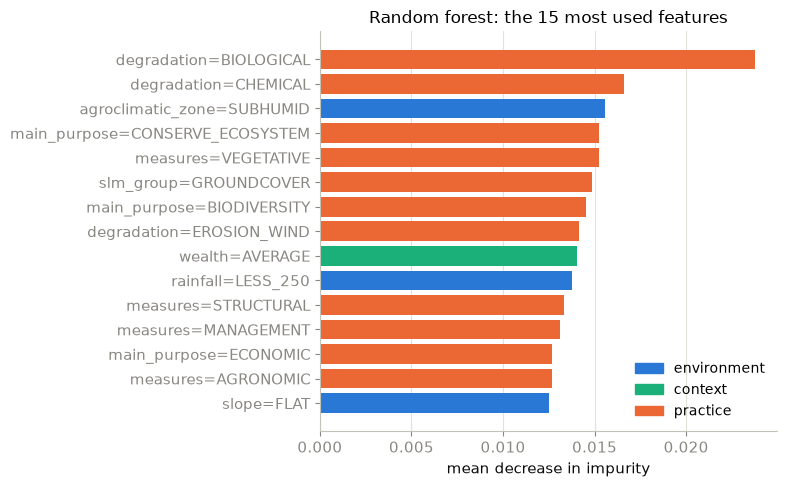

                                       block  prevalence  share high | present  share high | absent  difference
degradation=BIOLOGICAL              practice       0.644                 0.550                0.379       0.171
degradation=CHEMICAL                practice       0.420                 0.532                0.459       0.073
agroclimatic_zone=SUBHUMID       environment       0.428                 0.415                0.545      -0.130
main_purpose=CONSERVE_ECOSYSTEM     practice       0.301                 0.576                0.452       0.124
measures=VEGETATIVE                 practice       0.496                 0.538                0.441       0.097
slm_group=GROUNDCOVER               practice       0.320                 0.538                0.466       0.072
main_purpose=BIODIVERSITY           practice       0.304                 0.566                0.456       0.110
degradation=EROSION_WIND            practice       0.251                 0.573                0.461     

In [6]:
forest = RandomForestClassifier(n_estimators=500, min_samples_leaf=2, random_state=SEED, n_jobs=-1).fit(X, y)
imp = pd.Series(forest.feature_importances_, index=X_df.columns).sort_values(ascending=False).head(15)
present = {f: (X_df[f] == 1).to_numpy() for f in imp.index}
direction = pd.DataFrame({"block": [BLOCK_OF[FIELD_OF[f]] for f in imp.index],
                          "prevalence": [present[f].mean() for f in imp.index],
                          "share high | present": [y[present[f]].mean() for f in imp.index],
                          "share high | absent": [y[~present[f]].mean() for f in imp.index]}, index=imp.index)
direction["difference"] = direction["share high | present"] - direction["share high | absent"]

fig, ax = plt.subplots(figsize=(8, 5))
colours = {"environment": C_BLUE, "context": C_AQUA, "practice": C_ORANGE}
ax.barh(imp.index[::-1], imp.values[::-1], color=[colours[BLOCK_OF[FIELD_OF[c]]] for c in imp.index[::-1]])
ax.legend(handles=[Patch(color=v, label=k) for k, v in colours.items()], loc="lower right")
ax.set_xlabel("mean decrease in impurity"); ax.set_title("Random forest: the 15 most used features"); tidy(ax, "x")
plt.tight_layout(); plt.show()
print(direction.round(3).to_string())

**Reading the forest.** The importance profile is flat (the top feature holds 2.4 % of the total,
the top 15 together 22 %): the signal is spread thinly over many weak indicators. The top of the
list is the compiler's *stated intent*: technologies that address *biological* degradation report a
high biodiversity gain 55 % of the time against 38 % for the rest, and the purposes "conserve
ecosystem" and "biodiversity" add +12 and +11 points. Vegetative measures (+10 points) are the one
mechanism-like feature. Environment enters through dryness with a twist: sub-humid sites report
lower gains, the driest sites (< 250 mm) the highest. Several top-15 features (economic purpose,
agronomic measures, flat slope) make no difference at all: they are in the chart because they split
often, not because they separate the classes — impurity importance is unsigned and favours frequent
features, which is why section 7.4 uses permutation importance instead.

## 5. Method 1 — a regularised deep feed-forward network

A multilayer perceptron on the 148 one-hot features, built with the Module 2 training toolbox:

| technique | what it does here |
|---|---|
| He initialisation | keeps activations at a sane scale through the layers |
| ReLU | non-saturating, no vanishing gradient |
| Batch normalisation | normalises inside the network, allows a larger learning rate (`use_bias=False` before it) |
| Dropout + L2 | the two regularisers that matter most with 900 rows |
| Adam | adaptive per-weight learning rates |
| `ReduceLROnPlateau` | halves the learning rate when the validation loss stalls |
| Early stopping | stops when the validation loss stops improving, restores the best weights |

We first show the failure mode without regularisation, then the regularised network, then tune it.

In [7]:
def dense_trunk(h, hidden=(128, 64), dropout=0.3, l2=1e-4, batchnorm=True, activation="relu", name="trunk"):
    reg = keras.regularizers.l2(l2) if l2 else None
    for i, units in enumerate(hidden):
        h = layers.Dense(units, kernel_initializer="he_normal", use_bias=not batchnorm, kernel_regularizer=reg)(h)
        if batchnorm:
            h = layers.BatchNormalization()(h)
        h = layers.Activation(activation, name=f"{name}_out" if i == len(hidden) - 1 else None)(h)
        if dropout:
            h = layers.Dropout(dropout)(h)
    return h

def build_mlp(hidden=(128, 64), dropout=0.3, l2=1e-4, batchnorm=True, activation="relu", lr=1e-3):
    inp = keras.Input(shape=(X.shape[1],), name="onehot")
    out = layers.Dense(1, activation="sigmoid", name="bio_high")(dense_trunk(inp, hidden, dropout, l2, batchnorm, activation))
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="binary_crossentropy", metrics=[keras.metrics.AUC(name="auc")])
    return model

def callbacks(patience=15):
    return [keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)]

def run_keras_cv(build, Xany, extra_targets=None, name=None, epochs=150, batch_size=32, seed=SEED):
    """Grouped 5-fold CV for a Keras model whose (first) output is the bio_high sigmoid.
    build(train_idx) returns a compiled model. Returns (fold scores, fitted models, histories)."""
    t0, out, models, histories = time.time(), [], [], []
    for k, (tr, te) in enumerate(FOLDS):
        keras.utils.clear_session(); keras.utils.set_random_seed(seed + k)
        tr_in, va_in = inner_split(tr, seed + k)
        target = (lambda idx: y[idx]) if extra_targets is None else (lambda idx: {"bio_high": y[idx], **{n: t[idx] for n, t in extra_targets.items()}})
        model = build(tr_in)
        h = model.fit(Xany[tr_in], target(tr_in), validation_data=(Xany[va_in], target(va_in)),
                      epochs=epochs, batch_size=batch_size, callbacks=callbacks(), verbose=0)
        pred = model.predict(Xany[te], verbose=0)
        p = (pred["bio_high"] if isinstance(pred, dict) else pred).ravel()
        out.append(scores_from(y[te], p)); models.append(model); histories.append(h.history)
    if name:
        record(name, out, time.time() - t0)
    return out, models, histories

build_mlp().summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ onehot (InputLayer)             │ (None, 148)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ trunk_out (Activation)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bio_high (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,969 (109.25 KB)

 Trainable params: 27,585 (107.75 KB)

 Non-trainable params: 384 (1.50 KB)

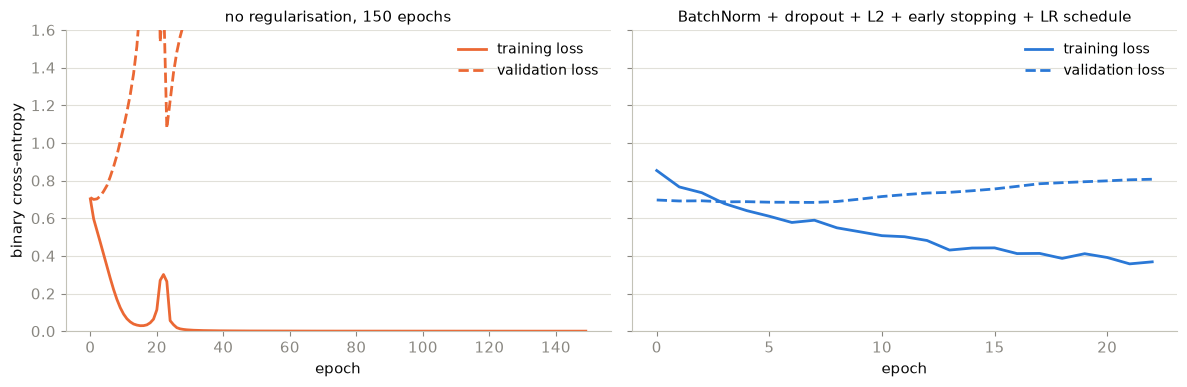

fold-0 test AUC: naive 0.542 (150 epochs)  |  regularised 0.516 (stopped after 23 epochs)


In [8]:
tr0, te0 = FOLDS[0]; tr_in0, va_in0 = inner_split(tr0)
keras.utils.set_random_seed(SEED)
naive = build_mlp(hidden=(256, 128), dropout=0.0, l2=0.0, batchnorm=False)
h_naive = naive.fit(X[tr_in0], y[tr_in0], validation_data=(X[va_in0], y[va_in0]), epochs=150, batch_size=32, verbose=0)
keras.utils.set_random_seed(SEED)
regular = build_mlp()
h_reg = regular.fit(X[tr_in0], y[tr_in0], validation_data=(X[va_in0], y[va_in0]), epochs=150, batch_size=32, callbacks=callbacks(), verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, hist, title, colour in [(axes[0], h_naive.history, "no regularisation, 150 epochs", C_ORANGE),
                                (axes[1], h_reg.history, "BatchNorm + dropout + L2 + early stopping + LR schedule", C_BLUE)]:
    ax.plot(hist["loss"], color=colour, linewidth=2, label="training loss")
    ax.plot(hist["val_loss"], color=colour, linewidth=2, linestyle="--", label="validation loss")
    ax.set_title(title, fontsize=11); ax.set_xlabel("epoch"); ax.legend(); tidy(ax)
axes[0].set_ylabel("binary cross-entropy"); axes[0].set_ylim(0, 1.6)
plt.tight_layout(); plt.show()
print(f"fold-0 test AUC: naive {roc_auc_score(y[te0], naive.predict(X[te0], verbose=0).ravel()):.3f} (150 epochs)  |  "
      f"regularised {roc_auc_score(y[te0], regular.predict(X[te0], verbose=0).ravel()):.3f} (stopped after {len(h_reg.history['loss'])} epochs)")

Left: the network memorises 600 rows of one-hot codes — training loss to zero, validation loss
rising from epoch ~10. Right: with the toolbox the validation loss stays near its starting value and
early stopping ends training after about twenty epochs. (The single-fold test AUCs printed above
are one fold of ~180 records and vary by a few hundredths between runs; the curves are the point.)

**Tuning.** Four configurations along the two axes that matter most on small data, width and
dropout, evaluated with the same grouped folds. (Picking the best of four on the folds we report is
slightly optimistic; nested cross-validation would remove that, at four candidates the effect is a
fraction of an AUC point.)

In [9]:
SWEEP = {"narrow (64), no dropout": dict(hidden=(64,), dropout=0.0, l2=0.0),
         "narrow (64), dropout 0.3": dict(hidden=(64,), dropout=0.3, l2=1e-4),
         "wide (256-128), no dropout": dict(hidden=(256, 128), dropout=0.0, l2=0.0),
         "wide (256-128), dropout 0.5": dict(hidden=(256, 128), dropout=0.5, l2=1e-4)}
sweep, best = [], None
for label, cfg in SWEEP.items():
    t0 = time.time()
    fold_scores, _, hists = run_keras_cv(lambda idx: build_mlp(**cfg), X)
    df = pd.DataFrame(fold_scores)
    sweep.append({"config": label, "AUC": df["AUC"].mean(), "AUC sd": df["AUC"].std(), "macro-F1": df["macro-F1"].mean(),
                  "epochs (mean)": np.mean([len(h["loss"]) for h in hists]), "seconds": time.time() - t0})
    if best is None or df["AUC"].mean() > best[1]:
        best = (label, df["AUC"].mean(), fold_scores, time.time() - t0)
print(pd.DataFrame(sweep).set_index("config").round(3).to_string())
record(f"1. Feed-forward net ({best[0]})", best[2], best[3])

                               AUC  AUC sd  macro-F1  epochs (mean)  seconds
config                                                                      
narrow (64), no dropout      0.523   0.054     0.506           18.4   18.204
narrow (64), dropout 0.3     0.530   0.050     0.502           19.6   14.688
wide (256-128), no dropout   0.554   0.022     0.499           16.8   15.033
wide (256-128), dropout 0.5  0.533   0.041     0.496           19.2   16.812
1. Feed-forward net (wide (256-128), no dropout) AUC 0.554 ± 0.022   macro-F1 0.499 ± 0.027   (  15 s)


All four configurations land between AUC 0.52 and 0.56, inside the fold-to-fold spread, so the grid
cannot separate them — with another seed a different one wins. What the regularisation toolbox buys
on this data is training that is stable and stops by itself, not a higher score. The tuned network
reaches AUC ≈ 0.55 — level with the random forest (0.56), not above it. On 900 rows of one-hot
answers a feed-forward network has no rich interactions to discover, and the yardsticks make that
visible.

## 6. Method 2 — a multi-task network for all eight biodiversity indicators

The research question is about *several* biodiversity numbers, and section 2 showed they are
correlated but not identical. So the network gets **two heads on one shared trunk**:

* `bio_high` — the same sigmoid classifier as method 1 (binary cross-entropy);
* `indicators` — eight linear outputs, one per indicator, trained with a **masked mean squared
  error** that ignores the indicators a compiler did not score (the mask zeroes the error where the
  label is `NaN` and divides by the number of labels present).

The total loss is the weighted sum (weight 0.5 on the indicator head). The trunk has to serve nine
targets at once, which regularises it, and the indicator head gives a prediction per indicator for
every technology — the basis of the heat-map in section 7.3.

**One detail we got wrong first.** With the indicator head's bias initialised at zero, early
stopping (which watches the *combined* validation loss, dominated by the classification head)
stopped after ~5 epochs, before the regression head had even learned the indicator means of
1.5–1.9. The per-indicator skill came out at −0.3 to −0.5, a training artefact. Initialising the
bias at the training means (`bias_initializer=Constant(...)`) removes it.

In [10]:
def masked_mse(y_true, y_pred):
    mask = keras.ops.logical_not(keras.ops.isnan(y_true))
    y_true = keras.ops.where(mask, y_true, keras.ops.zeros_like(y_true))
    m = keras.ops.cast(mask, y_pred.dtype)
    return keras.ops.sum(keras.ops.square(y_true - y_pred) * m) / keras.ops.maximum(keras.ops.sum(m), 1.0)

def masked_mae(y_true, y_pred):
    mask = keras.ops.logical_not(keras.ops.isnan(y_true))
    y_true = keras.ops.where(mask, y_true, keras.ops.zeros_like(y_true))
    m = keras.ops.cast(mask, y_pred.dtype)
    return keras.ops.sum(keras.ops.abs(y_true - y_pred) * m) / keras.ops.maximum(keras.ops.sum(m), 1.0)

def build_multitask(indicator_bias=None, hidden=(128, 64), dropout=0.3, l2=1e-4, lr=1e-3, indicator_weight=0.5):
    inp = keras.Input(shape=(X.shape[1],), name="onehot")
    h = dense_trunk(inp, hidden, dropout, l2)
    out_high = layers.Dense(1, activation="sigmoid", name="bio_high")(h)
    bias_init = keras.initializers.Constant(indicator_bias) if indicator_bias is not None else "zeros"
    out_ind = layers.Dense(len(BIO), name="indicators", bias_initializer=bias_init)(h)
    model = keras.Model(inp, {"bio_high": out_high, "indicators": out_ind})
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss={"bio_high": "binary_crossentropy", "indicators": masked_mse},
                  loss_weights={"bio_high": 1.0, "indicators": indicator_weight},
                  metrics={"bio_high": [keras.metrics.AUC(name="auc")], "indicators": [masked_mae]})
    return model

scores_C, models_C, hists_C = run_keras_cv(lambda idx: build_multitask(indicator_bias=np.nanmean(Y_IND[idx], axis=0)),
                                           X, extra_targets={"indicators": Y_IND}, name="2. Multi-task net (8 indicators + high/low)")

2. Multi-task net (8 indicators + high/low) AUC 0.545 ± 0.031   macro-F1 0.501 ± 0.023   (  25 s)


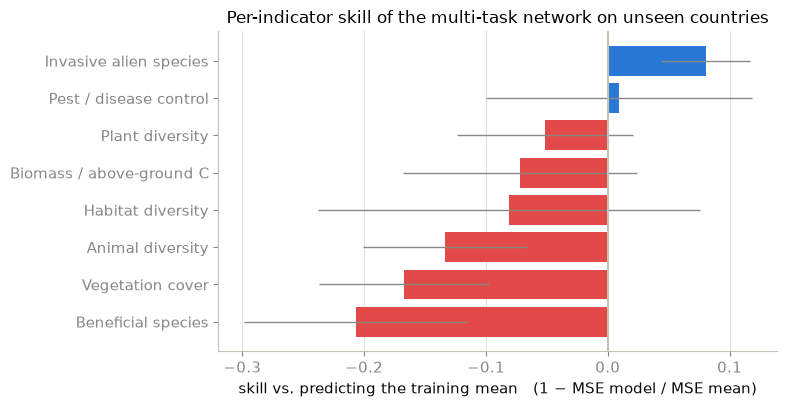

                            n  skill     sd
indicator                                  
Beneficial species        281 -0.207  0.092
Vegetation cover          350 -0.167  0.070
Animal diversity          249 -0.134  0.067
Habitat diversity         338 -0.081  0.157
Biomass / above-ground C  479 -0.072  0.096
Plant diversity           475 -0.052  0.072
Pest / disease control    255  0.009  0.109
Invasive alien species     98  0.081  0.037


In [11]:
rows = []
for model, (tr, te) in zip(models_C, FOLDS):
    pred = model.predict(X[te], verbose=0)["indicators"]
    for j, b in enumerate(BIO):
        m = ~np.isnan(Y_IND[te, j])
        if m.sum() < 5:
            continue
        mse_model = np.mean((Y_IND[te, j][m] - pred[m, j]) ** 2)
        mse_mean = np.mean((Y_IND[te, j][m] - np.nanmean(Y_IND[tr, j])) ** 2)
        rows.append({"indicator": PRETTY[b], "n": int(m.sum()), "skill": 1 - mse_model / mse_mean})
skill = pd.DataFrame(rows).groupby("indicator").agg(n=("n", "sum"), skill=("skill", "mean"), sd=("skill", "std")).sort_values("skill")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(skill.index, skill["skill"], xerr=skill["sd"], color=[C_BLUE if s >= 0 else C_RED for s in skill["skill"]], error_kw=dict(ecolor=INK_MUTED, lw=1))
ax.axvline(0, color=NEUTRAL); ax.set_xlabel("skill vs. predicting the training mean   (1 − MSE model / MSE mean)")
ax.set_title("Per-indicator skill of the multi-task network on unseen countries"); tidy(ax, "x")
plt.tight_layout(); plt.show()
print(skill.round(3).to_string())

**Reading the skill plot.** Every bar sits between −0.2 and +0.1: on unseen countries the network
predicts each biodiversity number *no better than that indicator's training mean*. The
questionnaire's environment and practice fields do not carry the information, not even for the
strongly inter-correlated vegetation cluster. This is a result, not a failure of the method: it is
the per-indicator version of Dima's warning, and it tells us to read the heat-map in 7.3 as the
model's *tendencies*, not as predictions. On the shared `bio_high` head the multi-task network is
level with method 1 (AUC 0.55, fold spread 0.03).

## 7. Results: which methods go with the largest reported biodiversity gains?

### 7.1 All models on the same folds

                                                    AUC  AUC sd  macro-F1  macro-F1 sd  balanced acc.  seconds
approach                                                                                                      
0a. Majority class                                0.500   0.000     0.338        0.003          0.500    0.016
0b. Logistic regression                           0.515   0.034     0.511        0.027          0.513    0.074
0c. Random forest                                 0.561   0.036     0.547        0.041          0.550    4.056
1. Feed-forward net (wide (256-128), no dropout)  0.554   0.022     0.499        0.027          0.523   15.033
2. Multi-task net (8 indicators + high/low)       0.545   0.031     0.501        0.023          0.507   24.729


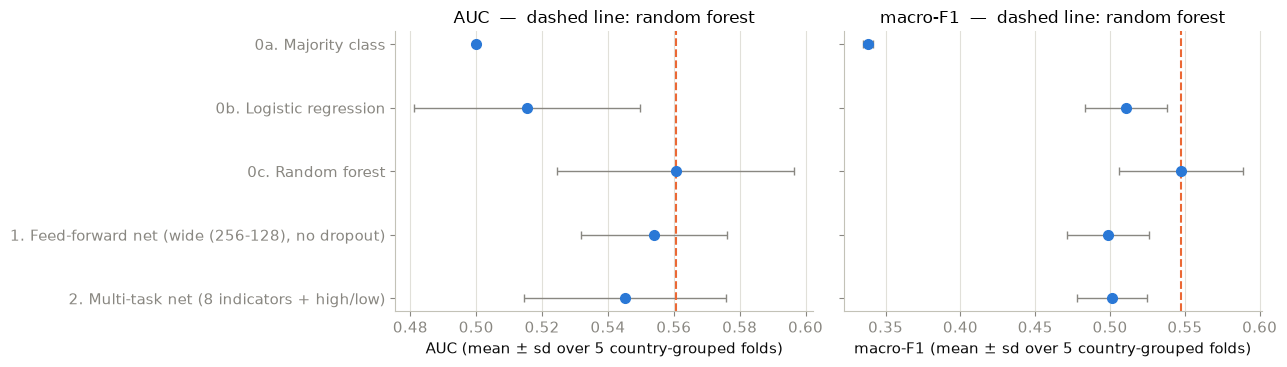

In [12]:
table = summary_table()
print(table.round(3).to_string())
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
names = list(table.index)
for ax, metric in zip(axes, ["AUC", "macro-F1"]):
    ax.errorbar(table[metric], range(len(names)), xerr=table[f"{metric} sd"], fmt="o", color=C_BLUE, ecolor=INK_MUTED, elinewidth=1, capsize=3, markersize=7)
    ax.axvline(table.loc["0c. Random forest", metric], color=C_ORANGE, linestyle="--", linewidth=1.5)
    ax.set_xlabel(f"{metric} (mean ± sd over 5 country-grouped folds)"); ax.set_title(f"{metric}  —  dashed line: random forest"); tidy(ax, "x")
axes[0].set_yticks(range(len(names)), names); axes[0].invert_yaxis()
plt.tight_layout(); plt.show()

Nothing beats the random forest, and nothing is more than a few hundredths above chance
(AUC 0.5). The fold-to-fold spread (± 0.03–0.04) is as large as the differences between models.
That is Dima's one-cell test ("knowing what was done adds nothing to knowing where") confirmed
with neural networks.

### 7.2 Raw ranking vs. environment-adjusted what-if

The raw ranking mixes what a method does with *where* it is used (forest technologies sit in humid
zones, water harvesting in arid ones). The multi-task network lets us separate the two with a
counterfactual: *if every one of the 895 technologies had used method g — in its own climate,
soil, slope and context — what would the network expect?* We switch every technology's SLM-group
indicator to *only* g, leave everything else untouched, predict with the five fold models and
average. Grey = raw share of "high" records among technologies listing the group; blue = the
what-if probability.

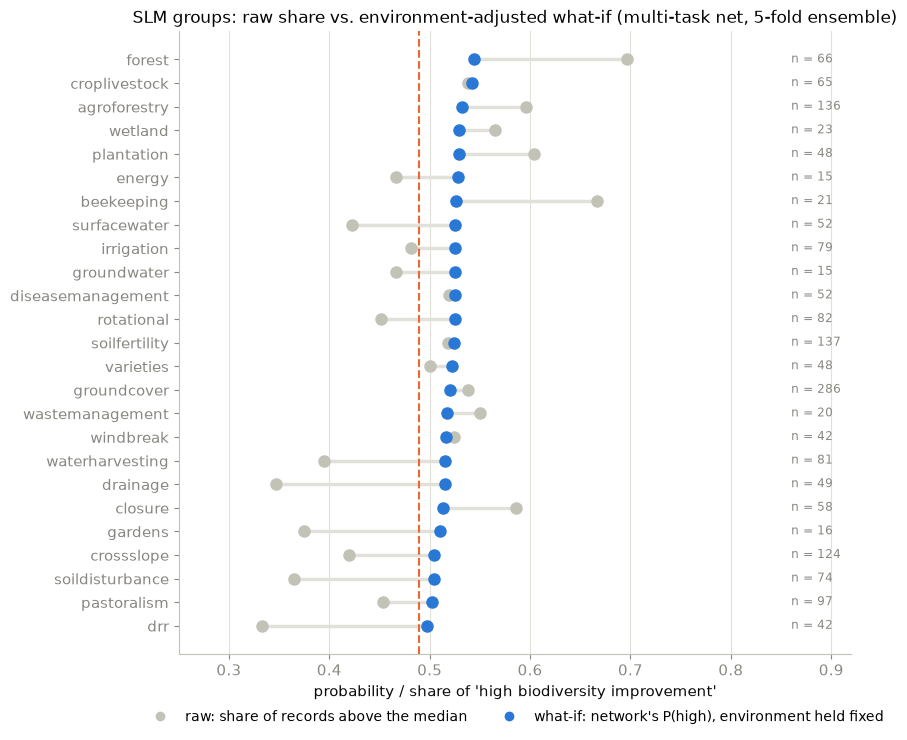

                     n  raw share high  adjusted P(high)
FOREST              66           0.697             0.544
CROPLIVESTOCK       65           0.538             0.542
AGROFORESTRY       136           0.596             0.532
PLANTATION          48           0.604             0.529
WETLAND             23           0.565             0.529
ENERGY              15           0.467             0.528
BEEKEEPING          21           0.667             0.527
IRRIGATION          79           0.481             0.525
ROTATIONAL          82           0.451             0.525
GROUNDWATER         15           0.467             0.525
DISEASEMANAGEMENT   52           0.519             0.525
SURFACEWATER        52           0.423             0.525
SOILFERTILITY      137           0.518             0.524
VARIETIES           48           0.500             0.522
GROUNDCOVER        286           0.538             0.520
WASTEMANAGEMENT     20           0.550             0.517
WINDBREAK           42         

In [13]:
long = data[["bio_high", "bio_mean"]].assign(group=tokens(data["slm_group"])).explode("group")
share_high = long.groupby("group")["bio_high"].mean()
n_group = long.groupby("group").size()
GROUPS_SHOWN = [g for g in n_group.index if n_group[g] >= 15 and g not in ("MISSING", "OTHER")]
SLM_COL = {c.split("=")[1]: j for j, c in enumerate(X_df.columns) if c.startswith("slm_group=")}

def what_if(models, category):
    Xc = X.copy(); Xc[:, list(SLM_COL.values())] = 0.0; Xc[:, SLM_COL[category]] = 1.0
    preds = [m.predict(Xc, verbose=0) for m in models]
    return (np.mean([p["bio_high"].ravel() for p in preds], axis=0).mean(),
            np.mean([p["indicators"] for p in preds], axis=0).mean(axis=0))

adjusted = {}
for g in GROUPS_SHOWN:
    p, ind = what_if(models_C, g)
    adjusted[g] = {"adjusted P(high)": p, **{b: v for b, v in zip(BIO, ind)}}
adjusted = pd.DataFrame(adjusted).T.astype(float)
adjusted["raw share high"] = share_high.reindex(adjusted.index); adjusted["n"] = n_group.reindex(adjusted.index)
adjusted = adjusted.sort_values("adjusted P(high)")

fig, ax = plt.subplots(figsize=(9, 7.5))
for i, (g, r) in enumerate(adjusted.iterrows()):
    ax.plot([r["raw share high"], r["adjusted P(high)"]], [i, i], color=GRID, linewidth=2.5, zorder=1)
    ax.plot(r["raw share high"], i, "o", color=NEUTRAL, markersize=8, zorder=2)
    ax.plot(r["adjusted P(high)"], i, "o", color=C_BLUE, markersize=8, zorder=3)
    ax.text(0.86, i, f"n = {int(r['n'])}", va="center", fontsize=8.5, color=INK_MUTED)
ax.plot([], [], "o", color=NEUTRAL, label="raw: share of records above the median")
ax.plot([], [], "o", color=C_BLUE, label="what-if: network's P(high), environment held fixed")
ax.axvline(y.mean(), color=C_ORANGE, linestyle="--", linewidth=1.5)
ax.set_yticks(range(len(adjusted)), [g.lower() for g in adjusted.index]); ax.set_xlim(0.25, 0.92)
ax.set_xlabel("probability / share of 'high biodiversity improvement'")
ax.set_title("SLM groups: raw share vs. environment-adjusted what-if (multi-task net, 5-fold ensemble)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.07), ncol=2); tidy(ax, "x")
plt.tight_layout(); plt.show()
print(adjusted[["n", "raw share high", "adjusted P(high)"]].round(3).sort_values("adjusted P(high)", ascending=False).to_string())

### 7.3 Which method helps which biodiversity number?

Two heat-maps with the same layout — rows are SLM groups in the what-if order, columns the eight
indicators, colour is the cell minus its column mean (blue = better than the typical method for
that indicator, red = worse). The first is purely descriptive (mean reported score of technologies
listing the group; blank where fewer than 8 scores). The second is the model's what-if. Where both
agree we have something to say; where only the raw map is coloured, we are looking at a handful of
records.

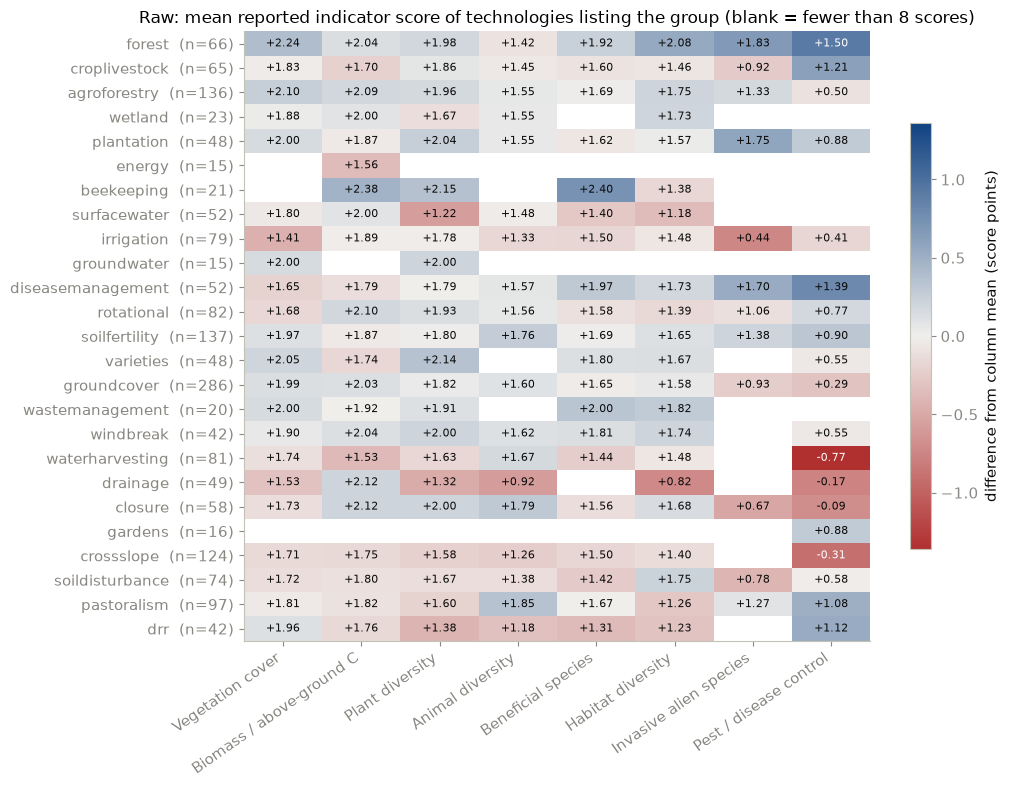

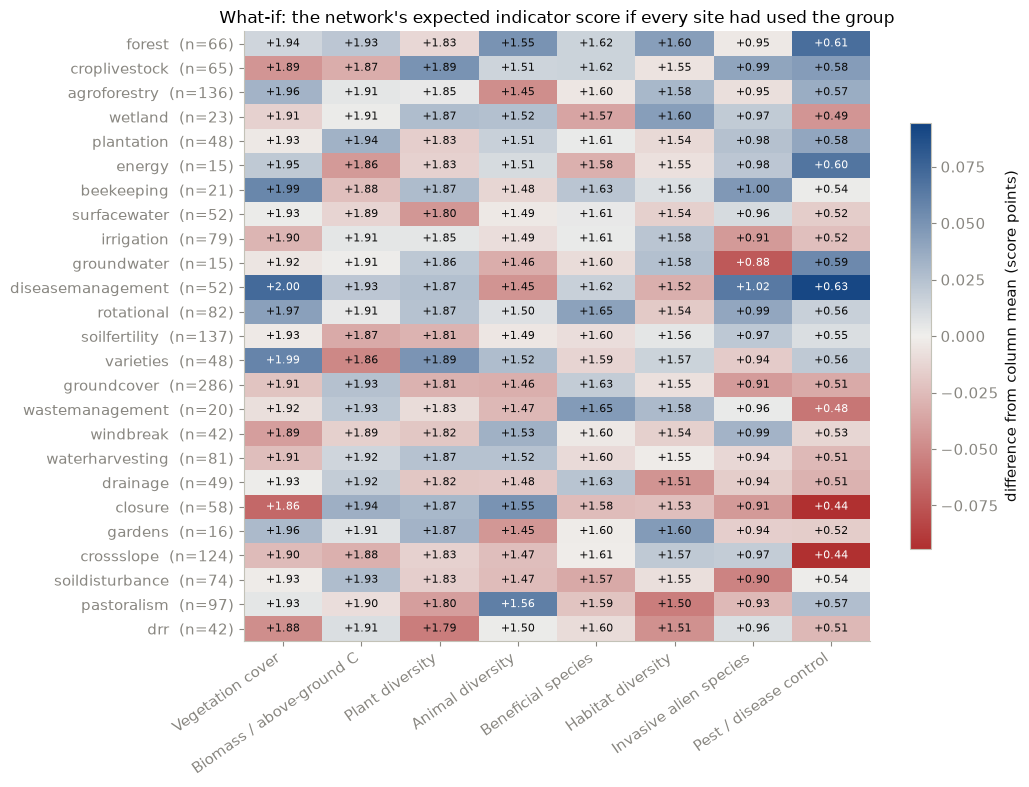

rank agreement raw vs what-if, per indicator (Spearman):
Vegetation cover            0.13
Biomass / above-ground C    0.31
Plant diversity             0.52
Animal diversity            0.36
Beneficial species          0.42
Habitat diversity           0.51
Invasive alien species      0.59
Pest / disease control      0.75


In [14]:
order = adjusted.sort_values("adjusted P(high)", ascending=False).index
long_ind = data[["technology_id"] + BIO].assign(group=tokens(data["slm_group"])).explode("group")
raw_agg = long_ind[long_ind["group"].isin(GROUPS_SHOWN)].groupby("group")[BIO].agg(["mean", "count"])
raw_mean = raw_agg.xs("mean", axis=1, level=1).reindex(columns=BIO).where(raw_agg.xs("count", axis=1, level=1).reindex(columns=BIO) >= 8).loc[order]

def plot_heat(values, title):
    centred = values - values.mean(axis=0); lim = float(np.nanmax(np.abs(centred.values)))
    fig, ax = plt.subplots(figsize=(10.5, 8))
    im = ax.imshow(np.ma.masked_invalid(centred.values), cmap=BLUE_RED.reversed(), vmin=-lim, vmax=lim, aspect="auto")
    ax.set_xticks(range(8), [PRETTY[b] for b in BIO], rotation=35, ha="right")
    ax.set_yticks(range(len(values)), [f"{g.lower()}  (n={int(adjusted.loc[g, 'n'])})" for g in values.index])
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            v = values.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8, color="white" if abs(centred.values[i, j]) > 0.6 * lim else INK)
    ax.set_title(title); fig.colorbar(im, ax=ax, shrink=0.7, label="difference from column mean (score points)"); tidy(ax, None)
    plt.tight_layout(); plt.show()

plot_heat(raw_mean, "Raw: mean reported indicator score of technologies listing the group (blank = fewer than 8 scores)")
plot_heat(adjusted[BIO].loc[order], "What-if: the network's expected indicator score if every site had used the group")
agreement = pd.Series({PRETTY[b]: raw_mean[b].corr(adjusted[b].loc[order], method="spearman") for b in BIO}).round(2)
print("rank agreement raw vs what-if, per indicator (Spearman):"); print(agreement.to_string())

### 7.4 Which feature blocks does the network actually use?

Permutation importance on the five test folds: shuffle one block of columns at a time (all columns
of the block together, so multi-hot rows stay valid) and measure the AUC the multi-task model loses.

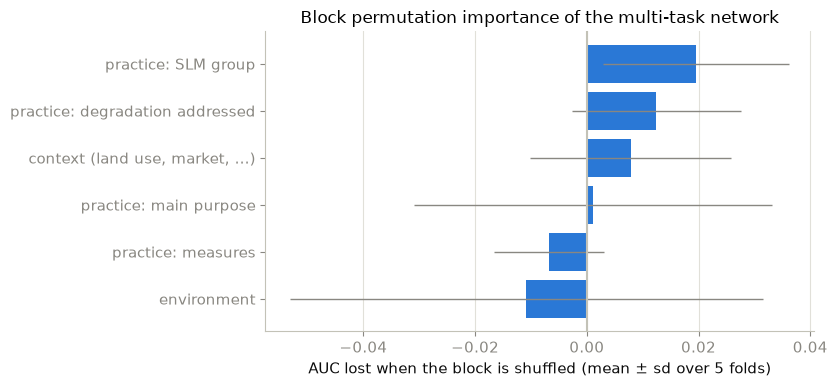

                                  mean    std
block                                        
environment                     -0.011  0.042
practice: measures              -0.007  0.010
practice: main purpose           0.001  0.032
context (land use, market, ...)  0.008  0.018
practice: degradation addressed  0.012  0.015
practice: SLM group              0.020  0.017


In [15]:
BLOCKS = {"environment": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] in ENVIRONMENT],
          "context (land use, market, ...)": [j for j, c in enumerate(X_df.columns) if BLOCK_OF[FIELD_OF[c]] == "context"],
          "practice: SLM group": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "slm_group"],
          "practice: measures": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "measures"],
          "practice: degradation addressed": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "degradation"],
          "practice: main purpose": [j for j, c in enumerate(X_df.columns) if FIELD_OF[c] == "main_purpose"]}
rng = np.random.default_rng(SEED); rows = []
for model, (tr, te) in zip(models_C, FOLDS):
    base = roc_auc_score(y[te], model.predict(X[te], verbose=0)["bio_high"].ravel())
    for name, cols in BLOCKS.items():
        drops = []
        for _ in range(5):
            Xp = X[te].copy(); Xp[:, cols] = Xp[rng.permutation(len(te))][:, cols]
            drops.append(base - roc_auc_score(y[te], model.predict(Xp, verbose=0)["bio_high"].ravel()))
        rows.append({"block": name, "AUC drop": np.mean(drops)})
block_imp = pd.DataFrame(rows).groupby("block")["AUC drop"].agg(["mean", "std"]).sort_values("mean")
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.barh(block_imp.index, block_imp["mean"], xerr=block_imp["std"], color=C_BLUE, error_kw=dict(ecolor=INK_MUTED, lw=1))
ax.axvline(0, color=NEUTRAL); ax.set_xlabel("AUC lost when the block is shuffled (mean ± sd over 5 folds)")
ax.set_title("Block permutation importance of the multi-task network"); tidy(ax, "x")
plt.tight_layout(); plt.show()
print(block_imp.round(3).to_string())

### 7.5 Synthesis

* **Vegetation-building methods lead.** Forest management, crop–livestock integration and
  agroforestry stay at the top after the environment is held fixed, with plantation just behind
  (wetland and beekeeping also rank high, but with n ≈ 20 their intervals span the whole axis). In
  the raw heat-map they lift the *vegetation* cluster of indicators — cover, biomass, plant and
  habitat diversity — rather than the two loners.
* **Holding the environment fixed compresses the ranking.** Raw shares run from 0.33
  (disaster-risk reduction) to 0.70 (forest); the what-if only from 0.50 to 0.54. Part of every
  method's raw advantage is *where it is used*: plantation, closure and beekeeping lose most of
  theirs; drainage and water harvesting climb from the bottom to the middle. The rest of the
  compression is the model's weakness — a network with AUC 0.55 cannot move a probability far
  from 0.5.
* **Soil- and water-engineering methods trail.** Cross-slope structures, soil-disturbance
  practices, pastoralism and disaster-risk reduction sit at the bottom in every view. This is not
  "they are bad for biodiversity": their compilers rate them for soil and water, and fill in the
  biodiversity block with less enthusiasm (or less relevance).
* **Pest / disease control and invasive species are a different axis.** They are the two
  indicators with a real share of negative scores, the least correlated with the rest, the two
  where the raw and what-if maps agree best (Spearman 0.75 and 0.59 against 0.1–0.5 for the
  vegetation cluster), and the columns in which disease management stands out in both maps.
* **The practice fields matter as much as the environment — which is to say, barely.** Shuffling
  the SLM group costs the network about 0.02 AUC, the degradation types addressed about 0.01,
  the environment nothing measurable. The whole signal is ≈ 0.05 AUC above chance, and different
  models spend it on different columns.

## 8. Conclusions and limitations

**Answer to the research question.** The WOCAT questionnaire fields predict a technology's
*reported* biodiversity improvement only weakly (AUC ≈ 0.55 on unseen countries, for every model
we tried), and the individual indicators not at all beyond their means. The methods associated
with the largest reported gains are the vegetation-building ones — forest management, crop–livestock
integration, agroforestry — and the association survives holding the environment fixed. The
strongest single predictors are the compiler's stated intent (addressing biological degradation,
conserving ecosystems), which says as much about how the forms are filled in as about the land.

**What the numbers cannot say.** Every score is one person's opinion of their own project, there
are no failures and no control plots, and compilers who documented many technologies rate
systematically higher or lower. The what-if is the network's belief about *reported* impact in a
counterfactual it never observed. It describes what the WOCAT community reports, not what works.

**Module 2 methods used.** A deep feed-forward network designed, trained, tuned and regularised
with the D1 toolbox (method 1); a multi-output network built with the functional API and a custom
masked loss (method 2, an extension of the course's multi-output and custom-loss examples); grouped
cross-validation and permutation importance for honest evaluation.

**What else we tried, and set aside.** *Entity embeddings* (a learned vector per questionnaire
category, functional API with 18 inputs): AUC 0.51, the weakest neural model, though its embedding
map of SLM groups is instructive. *Transfer learning* from the other impact blocks (pre-train a
trunk on soil, water, production, … scores; freeze; fine-tune): AUC 0.53 frozen, 0.54 fine-tuned,
no gain over training from scratch — tabular one-hot inputs have little reusable structure and the
source labels share the rater bias. *Text and photographs* (CNN, sequence models) would need the
WOCAT API token to fetch the raw records, and predicting the score from the compiler's own
description is circular. An RNN on the questionnaire has nothing sequential to model.

**Next steps if we continue.** Check whether the 645 technologies *without* a biodiversity score
differ systematically from the 895 with one (selection bias of everything above); quantify the
compiler effect directly (random vs country-grouped vs compiler-grouped splits, compiler as an
input); and flip the target to the practice itself (environment → SLM group, a clean label with a
practical use).

## Appendix — how to run

* Open from the repository root; the notebook finds `colab/datasets/wocat/` by walking up from the
  working directory. No API token is needed (Dima's cached CSVs).
* Kernel "Python (CAS AML)": Python 3.13, TensorFlow 2.21 (CPU), Keras 3, scikit-learn 1.9,
  pandas 3. Any environment with those packages works.
* Full run ≈ 10 minutes on a laptop CPU; TensorFlow's import alone takes ~40 s. Seeds are fixed:
  the classical yardsticks, the multi-task results and everything derived from them reproduce
  exactly; the feed-forward grid can shift by a few hundredths of AUC between machines and thread
  counts — which is the size of the differences it reports.